## Prepare dataset

In [2]:
import torch 

print(torch.__version__)
print(torch.cuda.is_available())


2.4.1+cu121
True


In [3]:
import os
from pathlib import Path

## How to organize the data

#### |--- DATAPATH/raw ---- patient.nii.gz
#### |--- DATAPATH_MASK/raw_mask ---- patient_mask.nii.gz
#### |--- DATAPATH_VESS/raw_vessel ---- patient_vessel.nii.gz

In [4]:
# COMMENT OUT ONE OF 2 BLOCKS BELOW DEPENDING ON THE DATASET YOU ARE USING
DATASET_NAME = "CT_TAS_GRENOBLE_TEST" # You can change but make sure it starts with "CT_"
DATA_PATH = "/data_network/summer_projects/geninana/Current/2020_AINI-Stroke_TC_BL/2025_AVA_Stroke/CT/tsa_50_nifti_test"
DATA_PATH = os.path.join(DATA_PATH, "raw")

DATASET_NAME = "TOF_TEST_ADAPT"  # You can change but make sure it starts with "TOF_" 
DATA_PATH = "/data_network/summer_projects/geninana/Current/2020_AINI-Stroke_TC_BL/2025_AVA_Stroke/IRM/TOF_nifti_TEST3"
DATA_PATH = os.path.join(DATA_PATH, "raw")

In [5]:
# # COMMENT OUT ONE OF 2 BLOCKS BELOW DEPENDING ON THE DATASET YOU ARE USING
# DATASET_NAME = "CT_GRENOBLE_5" # You can change but make sure it starts with "CT_"
# DATA_PATH = "/data_network/summer_projects/geninana/Current/2020_AINI-Stroke_TC_BL/2025_AVA_Stroke/CT/willis_test_nifti"
# DATA_PATH = os.path.join(DATA_PATH, "raw")


In [6]:

assert DATASET_NAME.startswith("CT_") or DATASET_NAME.startswith("TOF_"), "DATASET_NAME must start with 'CT_' or 'TOF_'"
assert os.path.isdir(DATA_PATH), "DATA_PATH must be a valid directory"
assert DATA_PATH.endswith("raw"), "DATA_PATH must end with 'raw'"

OUT_DIR = f"/home/geninana/data_ssd/DqnieleF/A2V_experiments/{DATASET_NAME}_preprocessed"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)


#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils
def img_path_to_brain_path(img_path):
    out_path = img_path.replace(".nii.gz", "_mask.nii.gz")

    out_path = out_path.replace("raw", "raw_mask") #for TOF_GRENOBLE
    
    if not os.path.isfile(out_path):
        return None # IF NO BRAIN MASKS ARE AVAILABLE (WHEN DOING INFERENCE)
    return out_path
def img_path_to_vessel_path(img_path):
    out_path = img_path.replace(".nii.gz", "_vessel.nii.gz")
    out_path = out_path.replace("raw", "raw_vessel") #for TOF_GRENOBLE
    if not os.path.isfile(out_path):
        return None # IF NO VESSEL MASKS ARE AVAILABLE (WHEN DOING INFERENCE)
    return out_path
def img_path_to_weight_path(img_path):
    return None

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = "^.*.nii.gz$"

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = []

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = False

#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = False

In [7]:
utils.img_path_to_brain_path = img_path_to_brain_path
utils.img_path_to_vessel_path = img_path_to_vessel_path
utils.img_path_to_weight_path = img_path_to_weight_path

### Extract paths

In [8]:
import os

from utils import search_nii, extract_paths, load_info_from_checkpoint

In [9]:
if not os.path.isfile(f"info_{DATASET_NAME}.pkl"):
    print("CREATING INFO FILE")
    info = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None,
    }
    search_nii(DATA_PATH, info["train"])
else:
    print("LOADING INFO FILE")
    info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

LOADING INFO FILE


### Display examples

In [10]:
import random

from utils import print_bold, load_and_display_middle_slice

[Example 01]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 696 768 168   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.26041666 0.26041666 0.5999997  0.021      0.
 0.         0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'TE=3.4;Time=170607.658;phase=1'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.20120478
quatern_c       : -0.057487443
quatern_d       : 0.037860

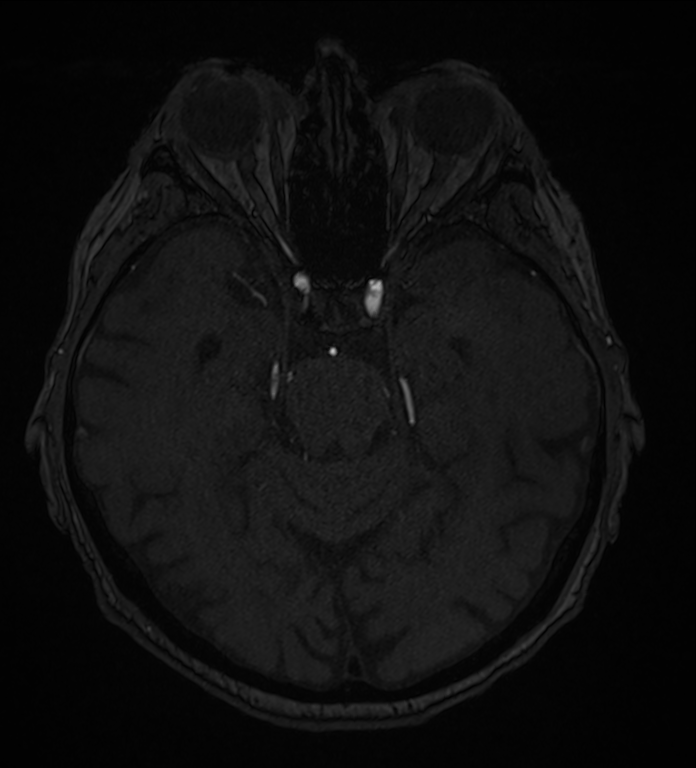

[Example 02]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 696 768 168   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.26041666 0.26041666 0.59999967 0.021      0.
 0.         0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'TE=3.4;Time=105204.913;phase=1'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.00059239723
quatern_c       : 0.024460886
quatern_d       : 0.009

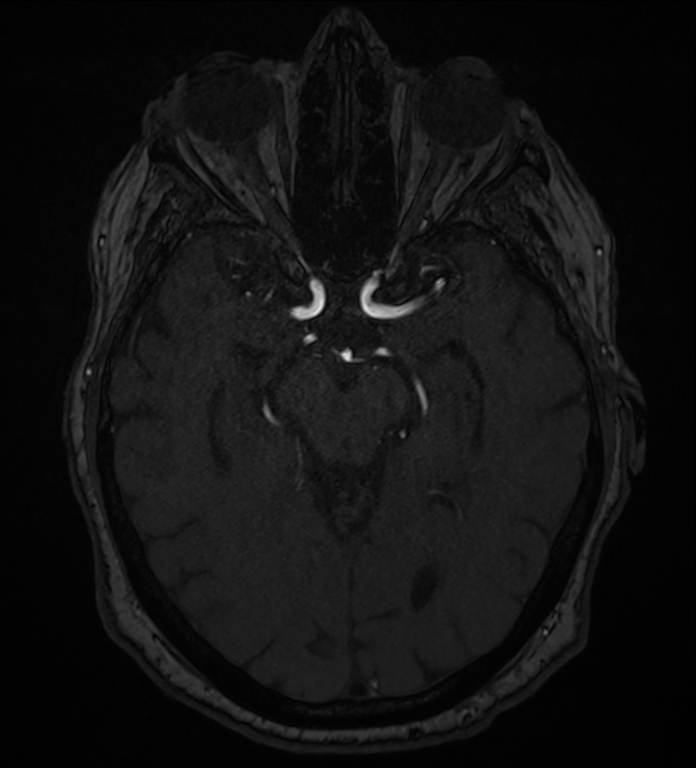

In [11]:
print_bold("[Example 01]")
random.seed(0)
try:
    load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)
except:
    print("No train data available, showing test data instead")
    load_and_display_middle_slice(random.choice(info["test"].paths), display_header=True)
print_bold("[Example 02]")
random.seed(1)
try:
    load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)
except:
    print("No train data available, showing test data instead")
    load_and_display_middle_slice(random.choice(info["test"].paths), display_header=True)

### Split train/val/test

In [12]:
from utils import is_medical_volume

In total, there are

In [13]:
IMGs = sum([
    info["train"].paths,
    info["val"].paths if info["val"] is not None else [],
    info["test"].paths if info["test"] is not None else []
], [])

len(IMGs)

19

volumes. First, we discard the outliers:

In [14]:
IMGs = [img_path for img_path in IMGs if os.path.basename(img_path) not in OUTLIERs]

len(IMGs)

19

We have vessel annotations for

In [15]:
HAVE_VESSELs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
]

len(HAVE_VESSELs)

12

of them. With a chosen ratio, we select

In [16]:
if len(HAVE_VESSELs) == 0:
    print("(No vessel masks available in the dataset: Every image will be used for testing)")
    COUNT_TEST = len(IMGs) * 100 // 100
else:
    COUNT_TEST = len(HAVE_VESSELs) * 30 // 100 # 

COUNT_TEST

3

images to be part of the validation/testing set.

In case brain masks are available, we collect them too.

In [17]:
HAVE_BRAINs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_brain_path(img_path))
]

len(HAVE_BRAINs)

12

Finally, we randomly split our dataset. 

In [18]:
random.seed(0)
NUM_TO_ADD = 0
try:
    VAL_IMGs = random.sample(sorted(HAVE_VESSELs), COUNT_TEST)
    TRAIN_IMGs = [img for img in HAVE_VESSELs if img not in VAL_IMGs]

except:
    VAL_IMGs = [] 
    TRAIN_IMGs = []

TEST_IMGs = [img for img in IMGs if img not in TRAIN_IMGs and img not in VAL_IMGs]


###############################3######################################################
# If you want to use some annotated data for testing, you can use the following code
# Otherwise, comment it out
if len(HAVE_VESSELs) > 0:
    random.seed(1)
    NUM_TO_ADD = 2
    TRAIN_TO_ADD = random.sample(sorted(TRAIN_IMGs), NUM_TO_ADD)
    TRAIN_IMGs = [img for img in TRAIN_IMGs if img not in TRAIN_TO_ADD]
    TEST_IMGs += TRAIN_TO_ADD
####################################################################################

print("train: ", [os.path.basename(img) for img in TRAIN_IMGs])
print("val: ", [os.path.basename(img) for img in VAL_IMGs])
print("test: ", [os.path.basename(img) for img in TEST_IMGs])

print_bold(f"\nTrain: {len(TRAIN_IMGs)}")
print_bold(f"Val: {len(VAL_IMGs)}")
print_bold(f"Test: {len(TEST_IMGs)} (Of which {NUM_TO_ADD} are annotated)")

assert len(TRAIN_IMGs) + len(VAL_IMGs) + len(TEST_IMGs) == len(IMGs), f"{len(TRAIN_IMGs)} + {len(VAL_IMGs)} + {len(TEST_IMGs)} = {len(TRAIN_IMGs) + len(VAL_IMGs) + len(TEST_IMGs)} != {len(IMGs)}"

train:  ['422838_Dataset_aini-stroke-10020_422838_TOF_tof_fl3d_tra_multi-slab_8_SLAB_20250127204407.nii.gz', '422855_Dataset_aini-stroke-10031_422855_TOF_TOF_20250127204218.nii.gz', '422864_Dataset_aini-stroke-10039_422864_TOF_tof_fl3d_tra_multi-slab_8_SLAB_20250127204147.nii.gz', '422871_Dataset_aini-stroke-10042_422871_TOF_TOF_RAPIDE_20250127204023.nii.gz', '422875_Dataset_aini-stroke-10041_422875_TOF_tof_fl3d_tra_multi-slab_8_SLAB_20250127203950.nii.gz', '422883_Dataset_aini-stroke-10036_422883_TOF_TOF_20250127203854.nii.gz', '422888_Dataset_aini-stroke-10033_422888_TOF_TOF_20250127203802.nii.gz']
val:  ['422866_Dataset_aini-stroke-10032_422866_TOF_TOF_20250127204056.nii.gz', '432678_Dataset_aini-stroke-20321_432678_TOF_TOF_3D_WILLIS_20250127140131.nii.gz', '422830_Dataset_aini-stroke-10024_422830_TOF_tof_fl3d_tra_multi-slab_8_SLAB_20250127204440.nii.gz']
test:  ['422802_Dataset_aini-stroke-10017_422802_TOF_TOF_20250127204711.nii.gz', '433140_Dataset_aini-stroke-13989_433140_TOF_TOF

In [167]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Extract spacings and shapes

In [168]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [169]:
from utils import extract_info_and_masks, loop_nii, display_info, get_target_spacing

In [170]:
info = {
    "train": extract_info_and_masks(path_rule=PATH_RULE),
    "val": extract_info_and_masks(path_rule=PATH_RULE),
    "test": extract_info_and_masks(path_rule=PATH_RULE),
}

loop_nii(TRAIN_IMGs, info["train"])
loop_nii(VAL_IMGs, info["val"])
loop_nii(TEST_IMGs, info["test"])

In [171]:
try:
    display_info(info["train"], info["val"])
except:
    print("No train data available, showing test data instead (2 TIMES)")
    display_info(info["test"],info["test"])

No train data available, showing test data instead (2 TIMES)


,#volumes,#slices,spacing median,spacing range,shape median,shape range
TRAIN,5,1372,[000.49 000.49 000.62],[000.42 000.42 000.62] - [000.52 000.52 000.62],[464.00 486.00 257.00],[415.00 427.00 224.00] - [512.00 512.00 336.00]
VAL,5,1372,[000.49 000.49 000.62],[000.42 000.42 000.62] - [000.52 000.52 000.62],[464.00 486.00 257.00],[415.00 427.00 224.00] - [512.00 512.00 336.00]


In [172]:
import numpy as np

try:
    SPACING = get_target_spacing(
        info["train"].spacings + info["val"].spacings,
        info["train"].shapesAfterCropping() + info["val"].shapesAfterCropping()
    )
    print(SPACING)
except:
    if DATASET_NAME.startswith("CT_"):
        SPACING = np.array([0.4453125 , 0.4453125 , 0.70001221])
    elif DATASET_NAME.startswith("TOF_"):
        SPACING = np.array([0.46875,0.4685,0.79999995])
    else:
        assert False, "DATASET_NAME must start with 'CT_' or 'TOF_'"

SPACING


array([0.4453125 , 0.4453125 , 0.70001221])

In [173]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Crop, Metadata, Resize, Empty Slices Removal, Standardization

In [174]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [175]:
import os

from utils import print_bold, preprocessing_loop

In [176]:
print_bold("Training")
preprocessing_loop(
    info["train"],
    os.path.join(OUT_DIR,"numpy", "train"),
    target_spacing=SPACING
)

print_bold("Validation")
preprocessing_loop(
    info["val"],
    os.path.join(OUT_DIR,"numpy", "val"),
    target_spacing=SPACING
)

print_bold("Testing")
preprocessing_loop(
    info["test"],
    os.path.join(OUT_DIR,"numpy", "test"),
    target_spacing=SPACING
)

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


...

Slices processed: 785
(512, 512, 257)
Target spacing: [0.4453125  0.4453125  0.70001221]
Current spacing: [0.419922 0.419922 0.625   ]
New shape: [438 403 229]
Resized shape: (438, 403, 229)
PASSED New shape: [512, 512]
New shape: [512 512 229]
Resized shape: (512, 512, 229)


 80%|████████  | 4/5 [03:36<00:52, 52.62s/it]

Slices processed: 1014
(512, 512, 236)
Target spacing: [0.4453125  0.4453125  0.70001221]
Current spacing: [0.466797 0.466797 0.625   ]
New shape: [435 519 211]
Resized shape: (435, 519, 211)
PASSED New shape: [512, 512]
New shape: [512 512 211]
Resized shape: (512, 512, 211)


100%|██████████| 5/5 [04:17<00:00, 51.43s/it]

Slices processed: 1225


In [177]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Outliers removal and slices extraction

In [178]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [179]:
import os

from utils import print_bold, extraction_loop, display_slice

In [180]:
print_bold("Training")
extraction_loop(
    info["train"],
    os.path.join(OUT_DIR,"slices", "train")
)

print_bold("Validation")
extraction_loop(
    info["val"],
    os.path.join(OUT_DIR,"slices", "val")
)

print_bold("Testing")
extraction_loop(
    info["test"],
    os.path.join(OUT_DIR,"slices", "test")
)

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


100%|██████████| 5/5 [00:06<00:00,  1.22s/it]


In [181]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Intensity values analysis

In [182]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [183]:
import numpy as np

from utils import intensity_loop, display_intensity
from utils import get_percentile, display_clipped_slice

In [184]:
try:
    print_bold("Training")
    intensity_loop(
        info["train"],
        min_value=min(info["train"].min_values + info["val"].min_values),
        max_value=max(info["train"].max_values + info["val"].max_values)
    )
    display_intensity(info["train"])

    print_bold("Validation")
    intensity_loop(
        info["val"],
        min_value=min(info["train"].min_values + info["val"].min_values),
        max_value=max(info["train"].max_values + info["val"].max_values)
    )
    display_intensity(info["val"])
except:
    print("JUST TESTING")

Training
JUST TESTING


In [185]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Normalization, Padding & Cropping, One-Hot Encoding

In [186]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [187]:
import numpy as np

from utils import display_slice, normalization_loop

In [188]:
try:
    MIN_VALUE = get_percentile(
        info["train"].bins,
        info["train"].intensity_count + info["val"].intensity_count,
        0.1
    )
    MAX_VALUE = get_percentile(
        info["train"].bins,
        info["train"].intensity_count + info["val"].intensity_count,
        99.9
    )
    print("Measure taken from training and validation sets")
except:
    print("JUST TESTING: Taking Data from the previous experiments")
    if DATASET_NAME.startswith("TOF_"):
        MIN_VALUE = -1.0472339080697863
        MAX_VALUE = 5.47153272794661
    elif DATASET_NAME.startswith("CT_"):
        MIN_VALUE = -1.5739588069435766
        MAX_VALUE = 3.0808791798780533
    else:
        assert False, "DATASET_NAME must start with 'CT_' or 'TOF_'"

print(MIN_VALUE, MAX_VALUE)

JUST TESTING: Taking Data from the previous experiments
-1.5739588069435766 3.0808791798780533


In [189]:
try:
    print_bold("Training")
    normalization_loop(info["train"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/train", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

    print_bold("Validation")
    normalization_loop(info["val"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/val", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE
except:
    print('Just Test')
print_bold("Testing")
normalization_loop(info["test"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/test", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


100%|██████████| 5/5 [00:17<00:00,  3.45s/it]


In [190]:
np.save(f"{OUT_DIR}/preprocess_map_{DATASET_NAME}.npy", {
    "train": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/train")),
    "val": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/val")),
    "test": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/test")),
})

In [193]:
# LOAD FROM THE PREPROCESSED DATA
print(slice_str)
OUT_TEST_DIR = os.path.join(OUT_DIR, f"preprocess_{DATASET_NAME}/test") 

print(f"Your preprocessed data is ready in {OUT_TEST_DIR}")

230
Your preprocessed data is ready in /home/geninana/data_ssd/DqnieleF/A2V_experiments/CT_GRENOBLE_5_preprocessed/preprocess_CT_GRENOBLE_5/test


Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


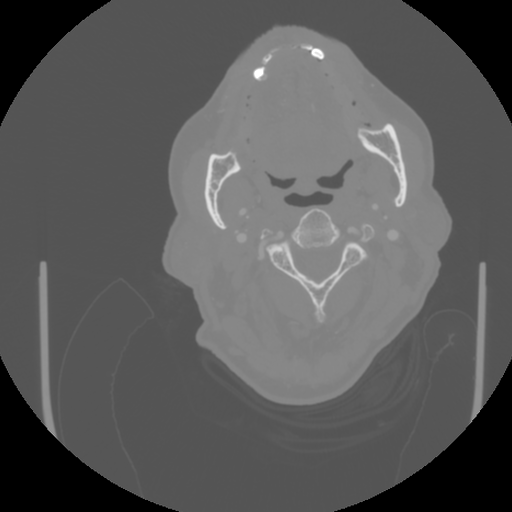

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


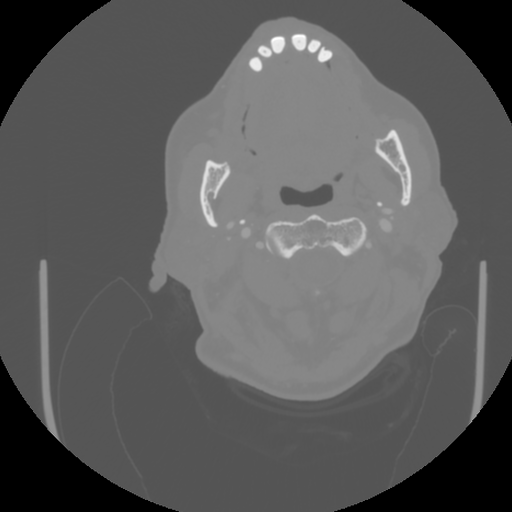

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


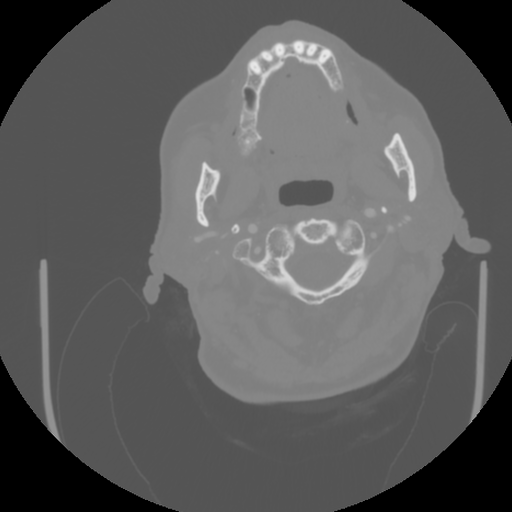

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


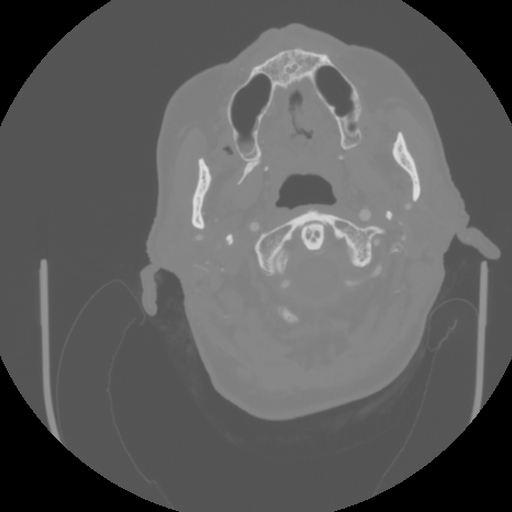

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


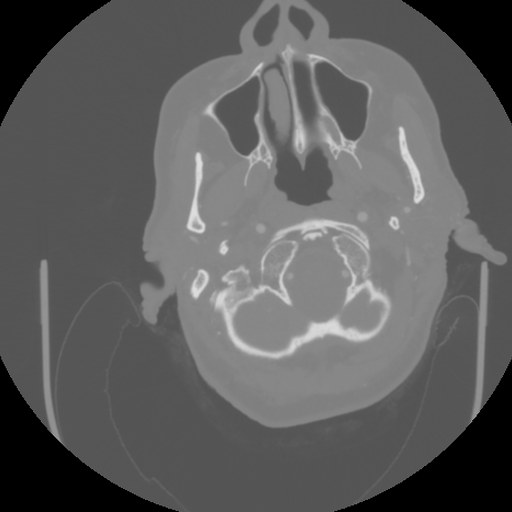

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


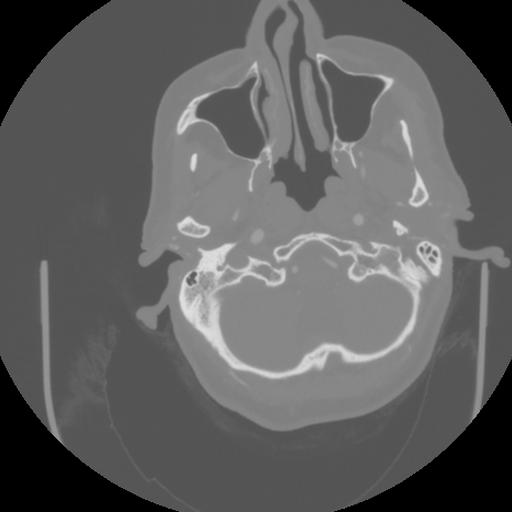

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


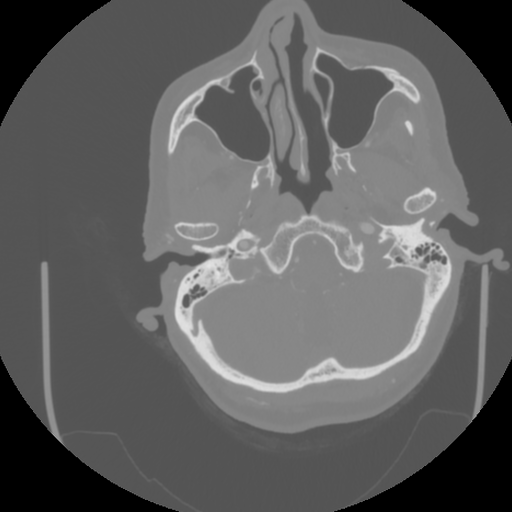

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


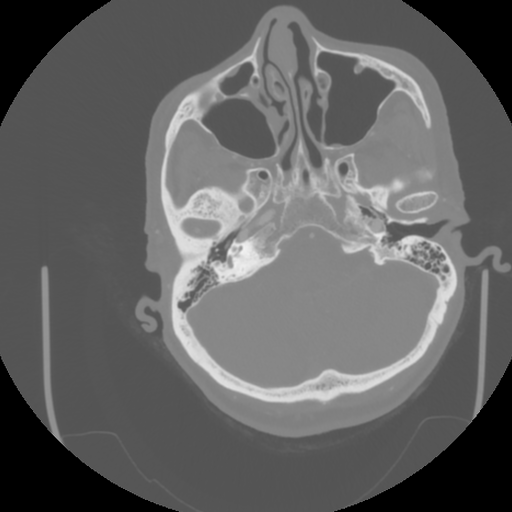

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


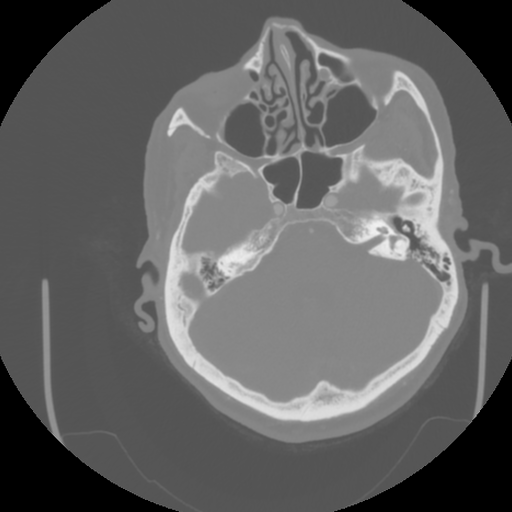

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


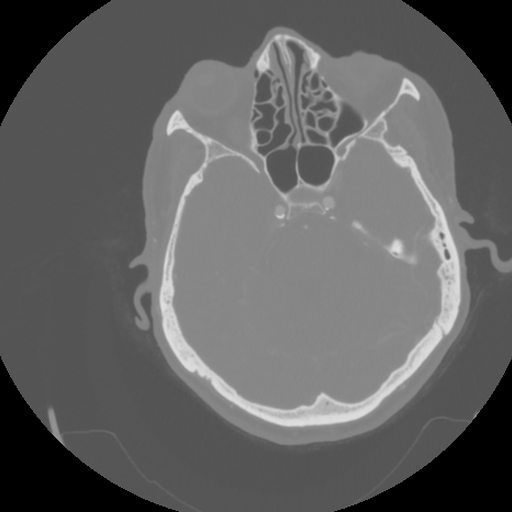

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


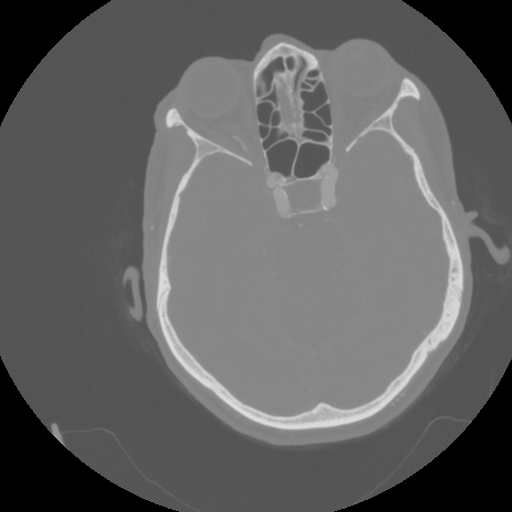

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


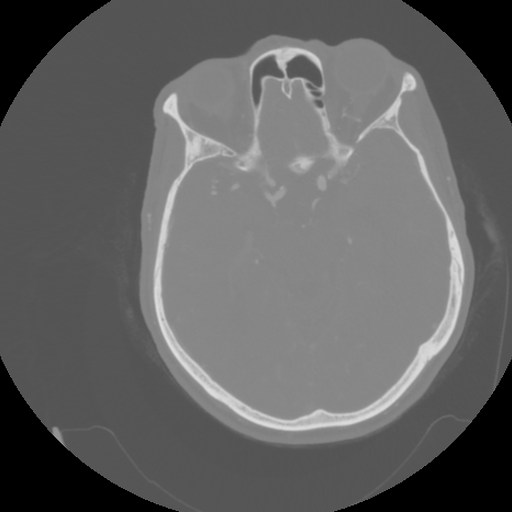

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


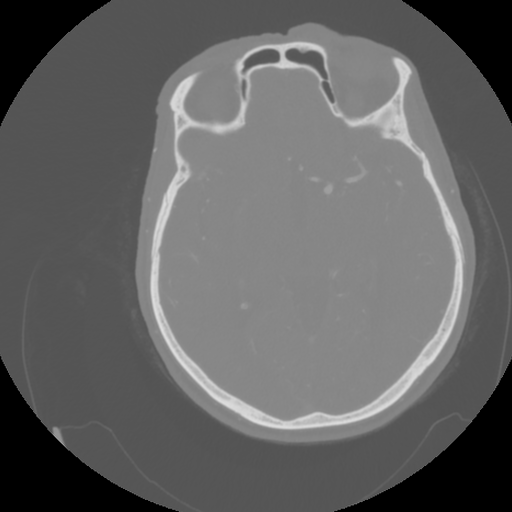

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


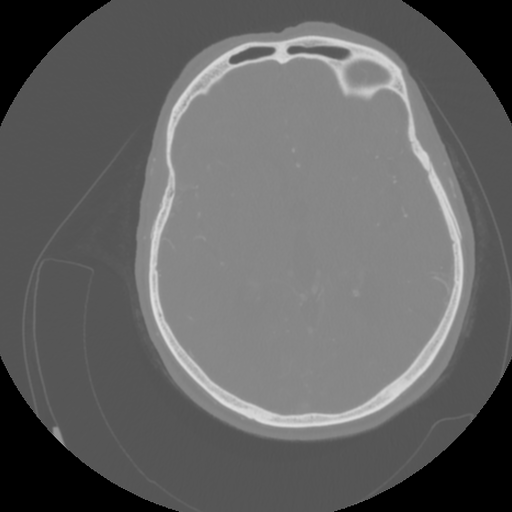

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


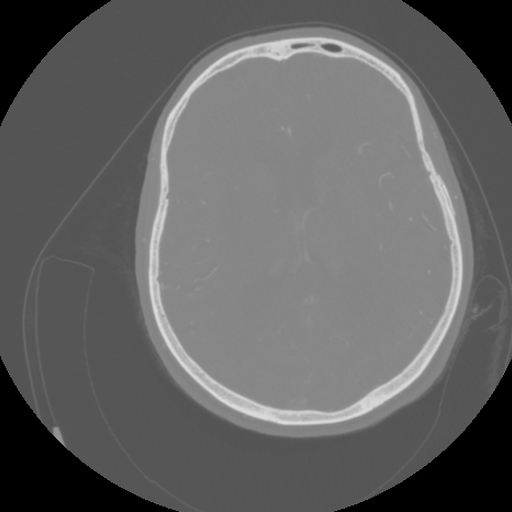

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


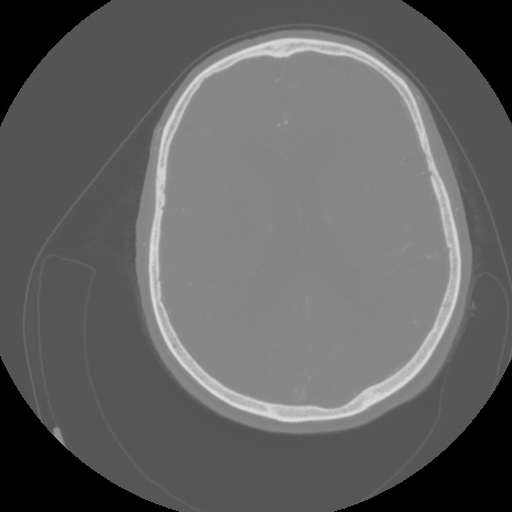

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


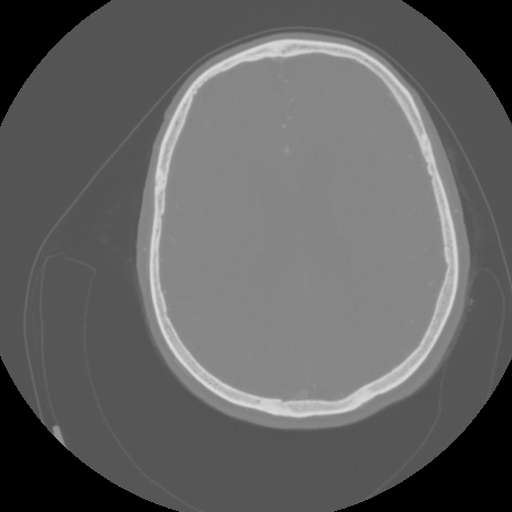

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


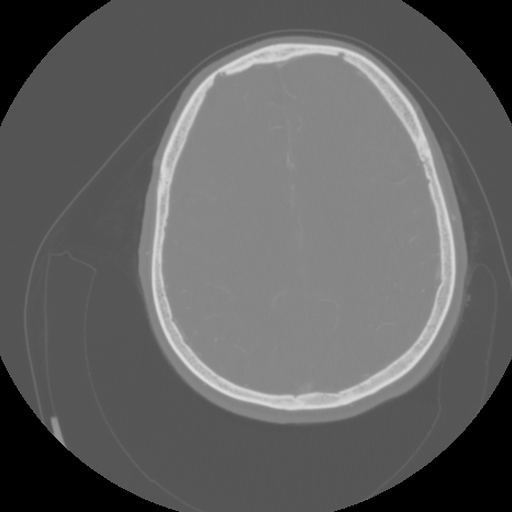

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


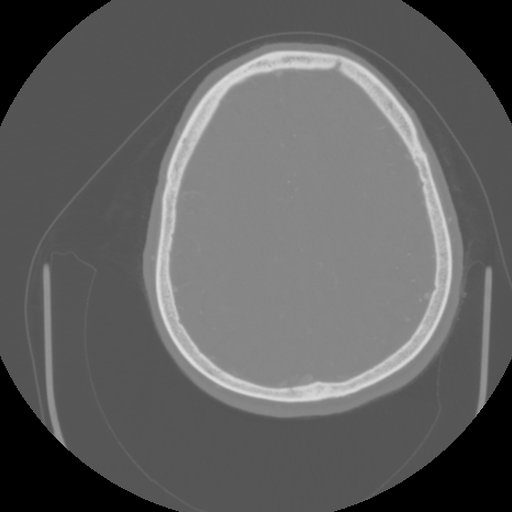

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321
(512, 512) (512, 512, 3)
(512, 512)


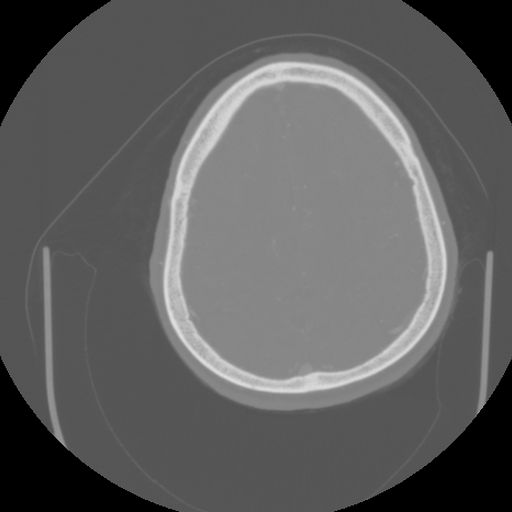

Plotting from 433119_Dataset_aini-stroke-15494_433119_Willis_Willis_20250131081321


In [194]:
# Take random example from the test set
random_example = np.random.choice(os.listdir(OUT_TEST_DIR)).split("_slice")[0]

for slice_num in range(0, 400, 10):
    # Format slice number with leading zeros
    slice_str = f"{slice_num:03d}"
    print(f"Plotting from {random_example}")
    # Load the specific slice
    try:
        img_example = np.load(
            os.path.join(OUT_TEST_DIR, f"{random_example}_slice{slice_str}.npy"), 
            allow_pickle=True
        ).item()
    except:
        break
    
    img_example, msk_example = img_example["data"][:,:,0], img_example["mask"]
    print(img_example.shape, msk_example.shape)
    msk_example = np.argmax(msk_example, axis=-1)
    print(msk_example.shape)

    display_slice(img_example, min_val=-1, max_val=1, mask=msk_example/2)